In [1]:
#Data loading
#Data Cleaning & EDA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#to view all columns
pd.set_option('display.max_columns',None)
#for a nict plot 
sns.set(style='whitegrid')

In [2]:
df=pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#basic dataset understanding
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [5]:
df.duplicated().sum() #no duplicate values

np.int64(0)

In [6]:
# check null or missing values
df.isnull().sum() # no missing or null values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.value_counts().sum()

np.int64(7043)

In [8]:
len(df)

7043

In [9]:
#check unique customer identifier
df['customerID'].nunique() #this ensures one row = one customer

7043

In [10]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [11]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [12]:
#as totalcharges in object here need to convert it to numeric
#Converts valid numbers correctly
#Converts invalid values (like " ") to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [13]:
#check missing values
df['TotalCharges'].isnull().sum()

np.int64(11)

In [14]:
#handle missing
df['TotalCharges'] = df['TotalCharges'].fillna(0)


In [15]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [16]:
df['TotalCharges'].dtype

dtype('float64')

In [17]:
#identify column categories

numerical_col=df.select_dtypes(include=['int64','float64']).columns

In [18]:

numerical_col

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [19]:
df_model = df.drop(columns=['customerID'])

#beacause it has unique values cannot plot it

In [20]:
categorical_col= df_model.select_dtypes(include='object').columns

In [21]:
categorical_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
## EDA
#What percentage of customers churn?
#Do new customers churn more?
#Does contract type affect churn?
#Are high-paying customers more likely to churn?
#Which services are linked with churn?

In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
df.shape

(7043, 21)

In [27]:
# 7043---no of rows---->no of customers
#21----no of columns---->features avaliable

In [28]:
df.info() #some feature like total charges stored as object ,require conversion

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [30]:
# taregt variable analysis
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [31]:
df['Churn'].value_counts(normalize=True)*100 # normalize= true turns counts into percentages

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [32]:
#Target analysis

#Univariate analysis

#Bivariate analysis

#Correlation

#Outliers

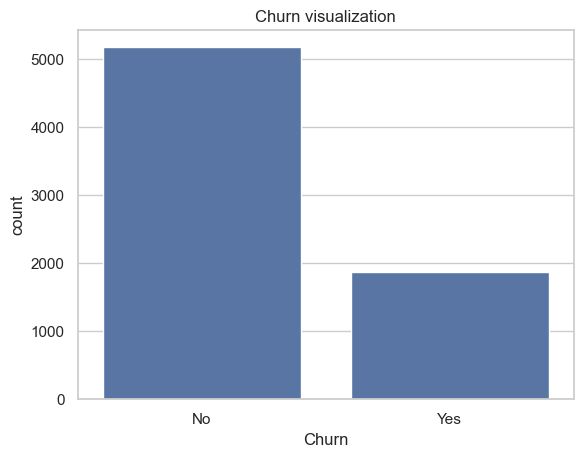

In [33]:
#Churn visualization
sns.countplot(data=df, x='Churn')
plt.title('Churn visualization')
plt.show()

In [34]:
# this plot shows imbalance dataset
# majority coustomer didnot churn

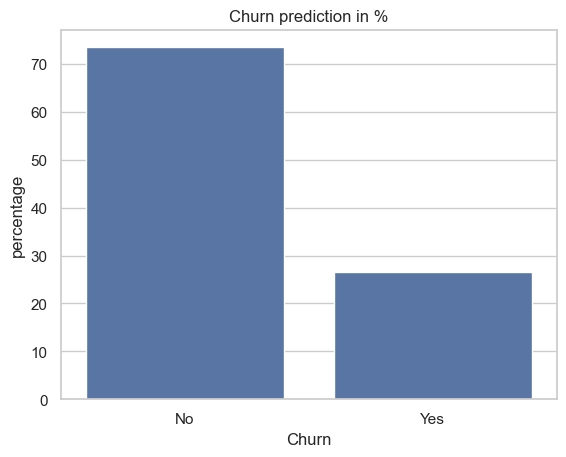

In [35]:
churn= df['Churn'].value_counts(normalize=True)*100 
sns.barplot(
    x= churn.index,
    y= churn.values
)
plt.ylabel('percentage')
plt.title('Churn prediction in %')
plt.show()

In [36]:
#approximately 25% coustomer churn, this indicates class imbalance problem

In [37]:
df['tenure'].skew() # >o so right skew
#Right skew	Mean > Median
#Left skew	Mean < Median
#Symmetric	Mean ≈ Median

np.float64(0.2395397495619829)

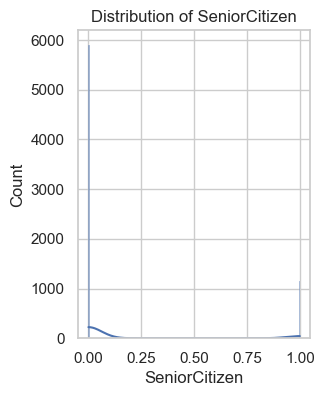

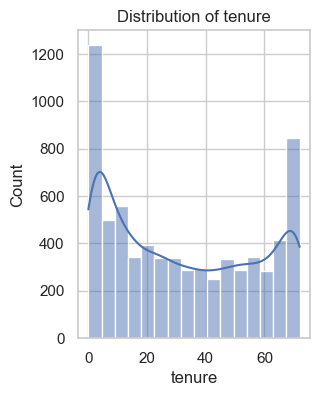

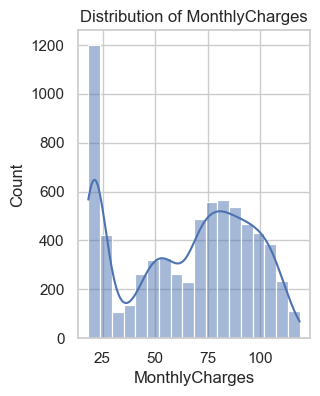

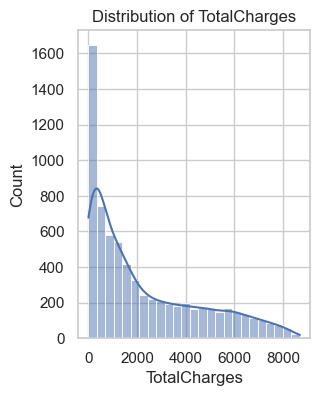

In [38]:
#univariant analysis of numerical values- analysing one variable at a time
for col in numerical_col:
    plt.figure(figsize=(3,4))
    sns.histplot(df[col],kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


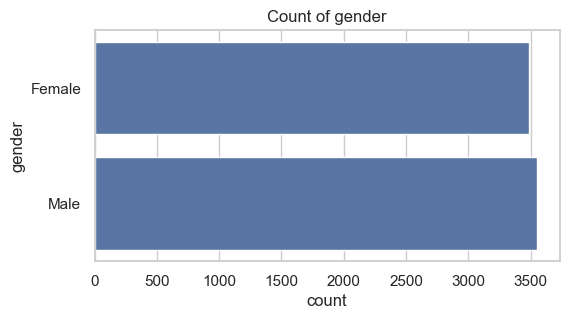

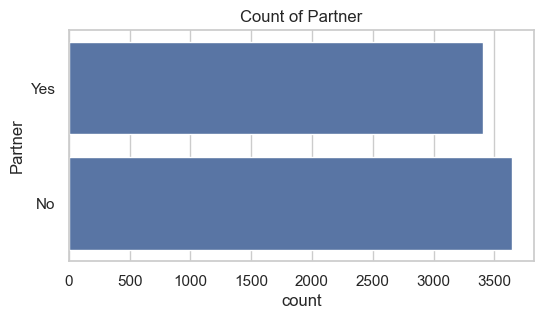

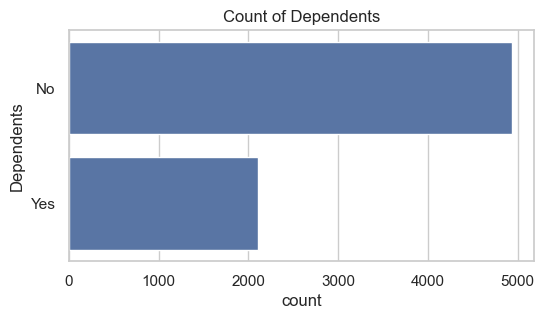

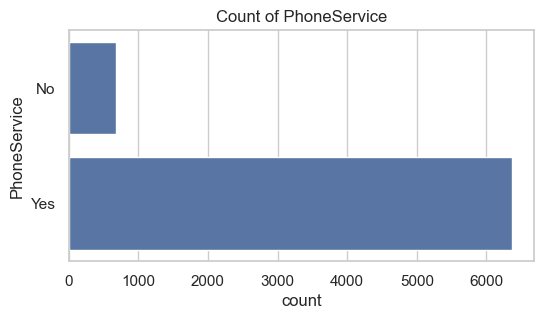

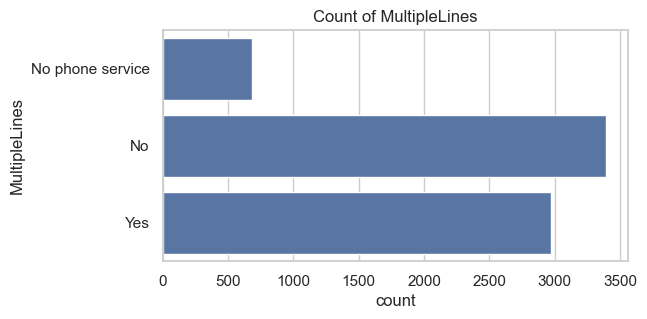

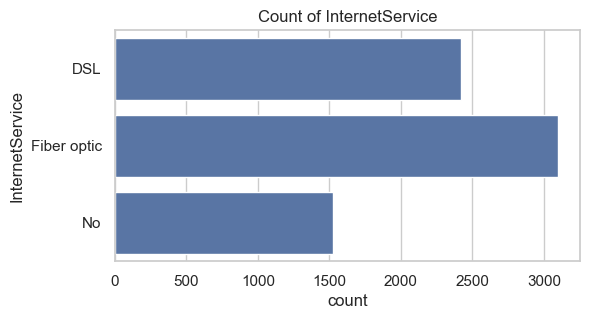

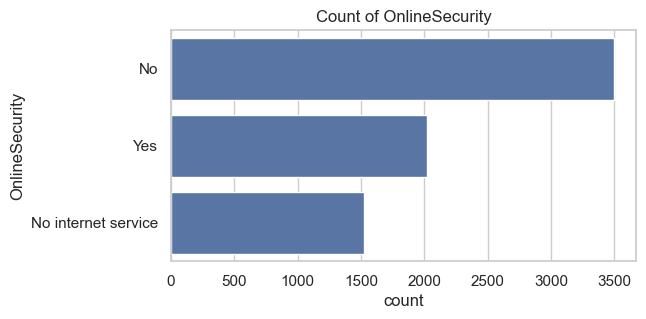

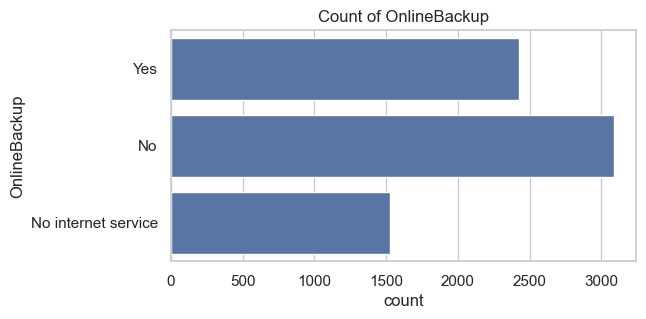

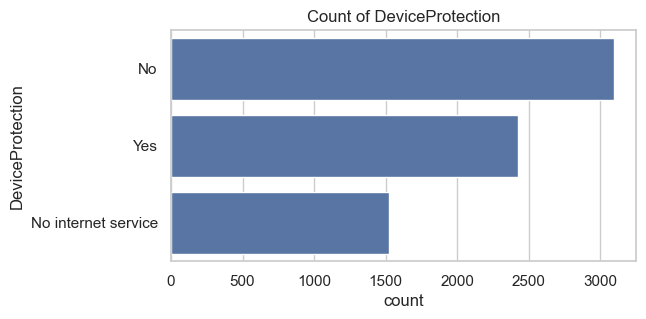

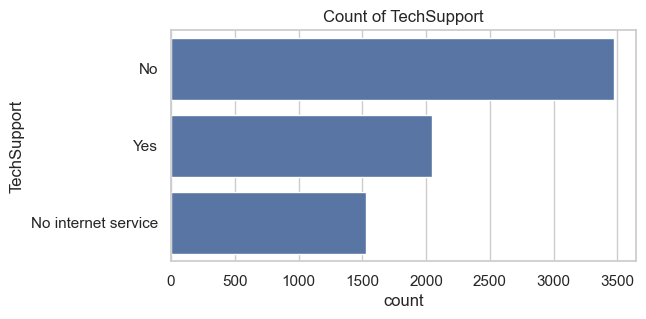

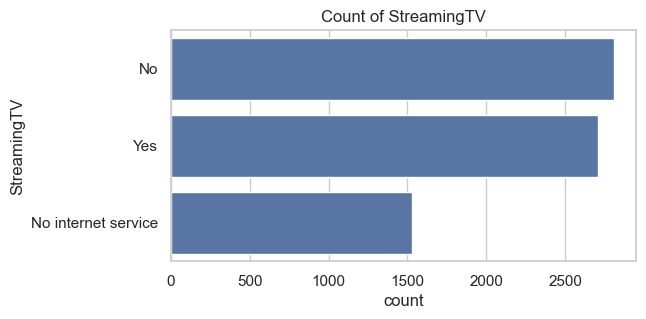

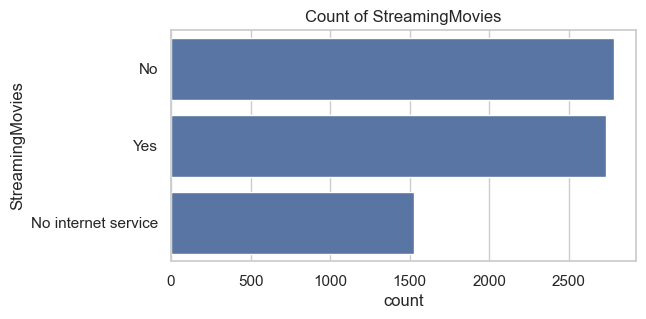

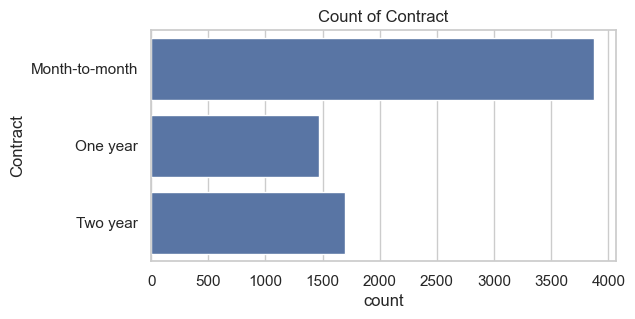

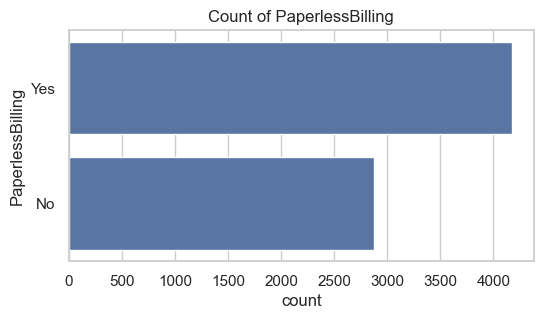

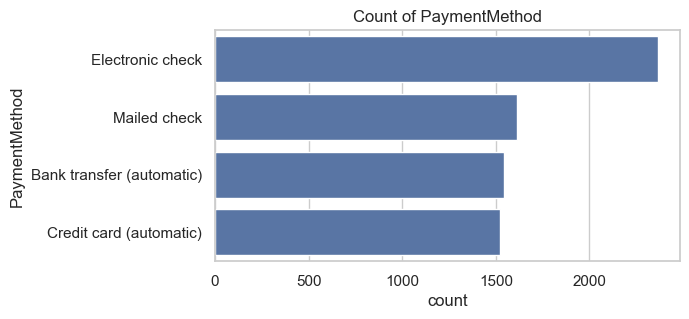

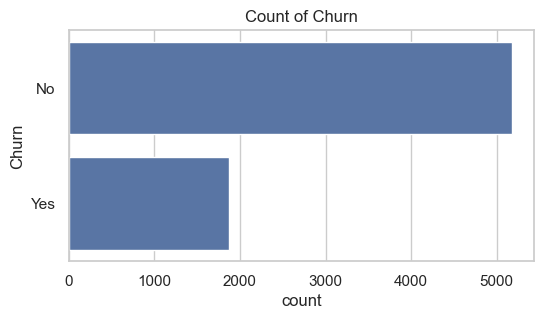

In [39]:
#univariate analysis of categorical features
for col in categorical_col:
    plt.figure(figsize=(6,3))
    sns.countplot(y=col, data=df)
    plt.title(f"Count of {col}")
    plt.show()


In [40]:
# bivarient analysis 
# analyse one numerical col one at a time using box plot

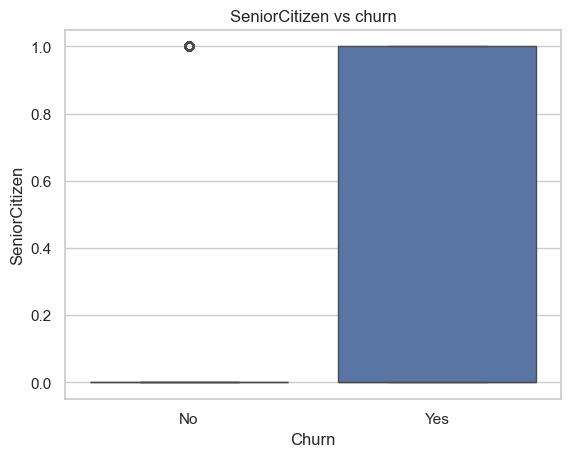

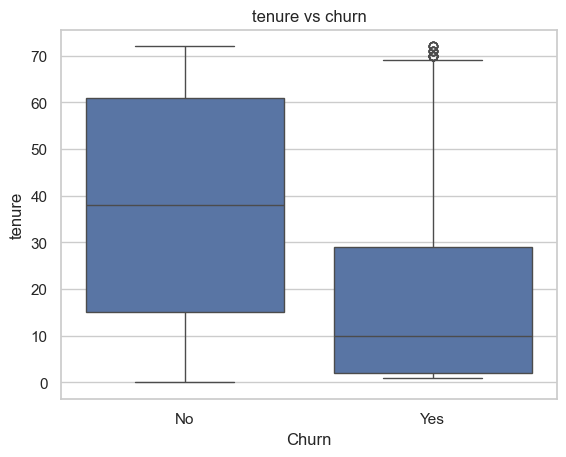

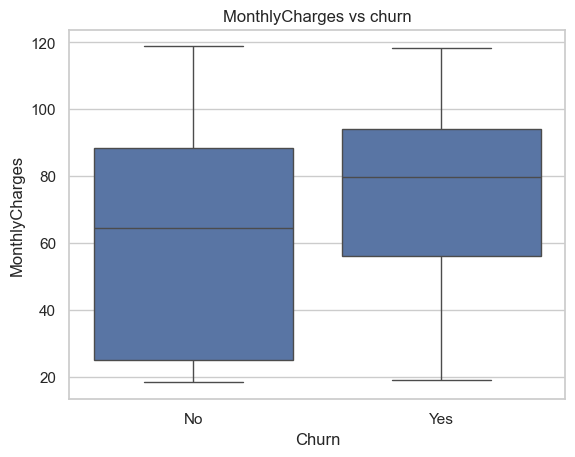

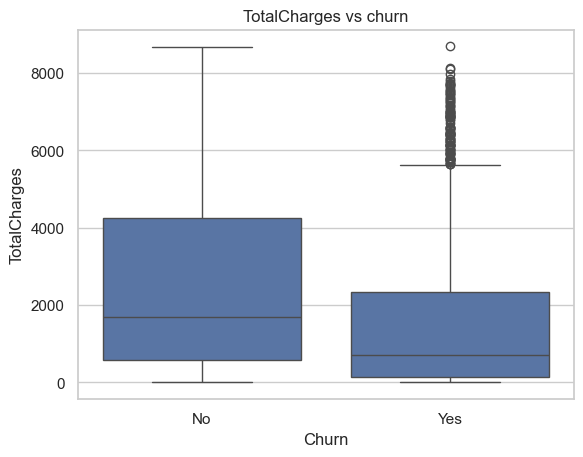

In [41]:
#numerical vs churn
for col in numerical_col:
    sns.boxplot(x='Churn',y=col,data=df)
    plt.title(f"{col} vs churn")
    plt.show()

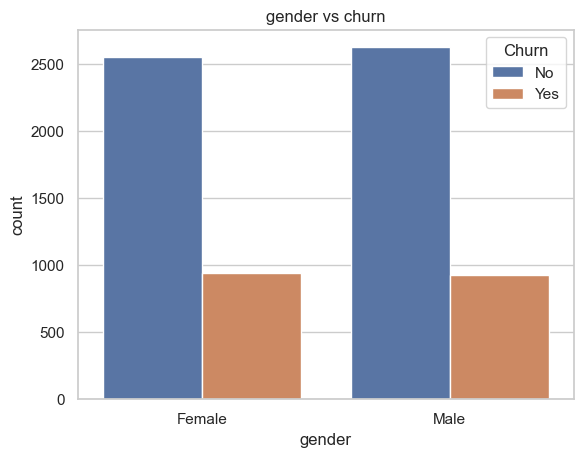

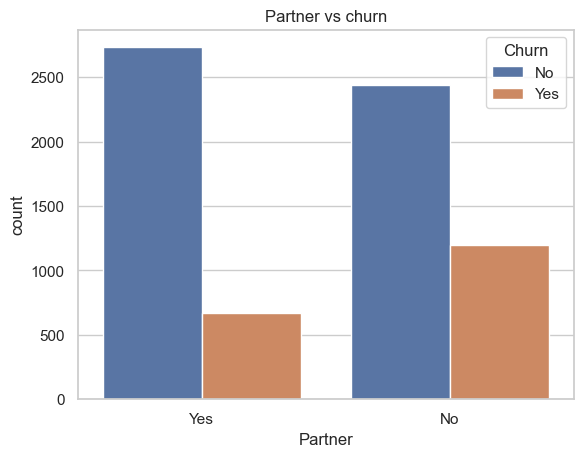

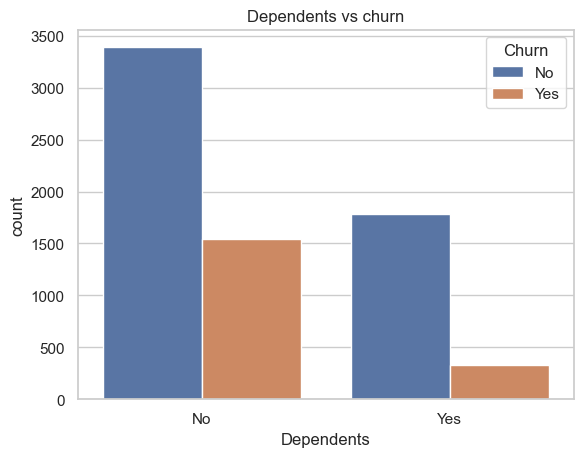

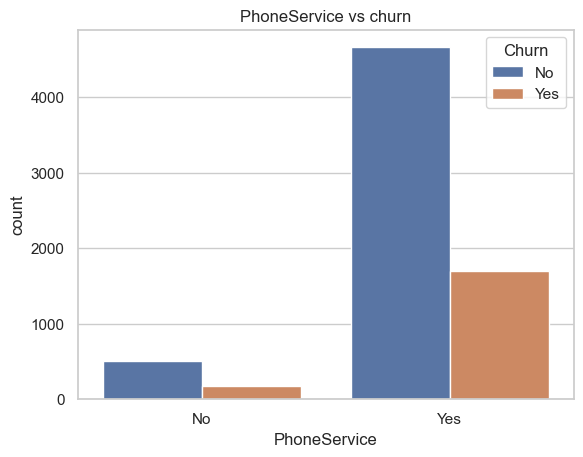

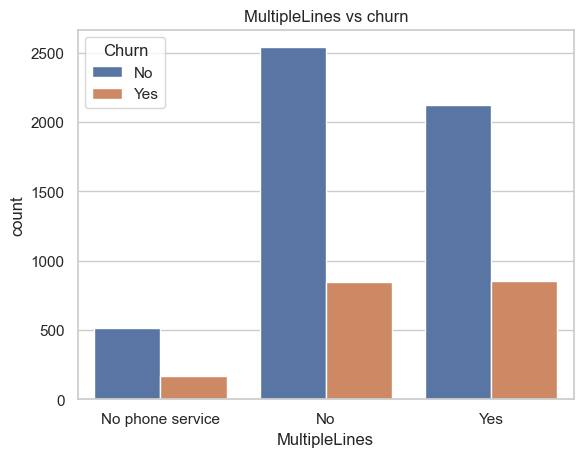

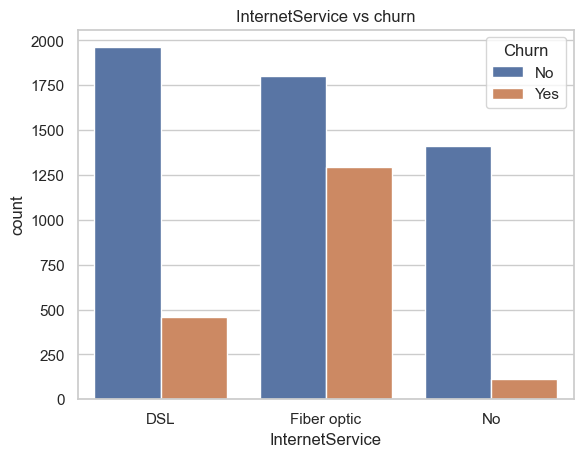

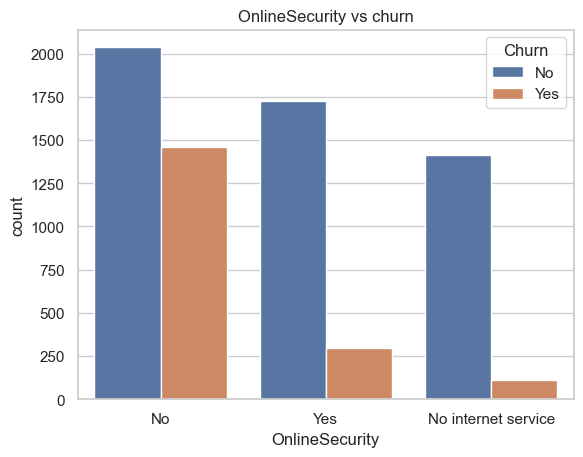

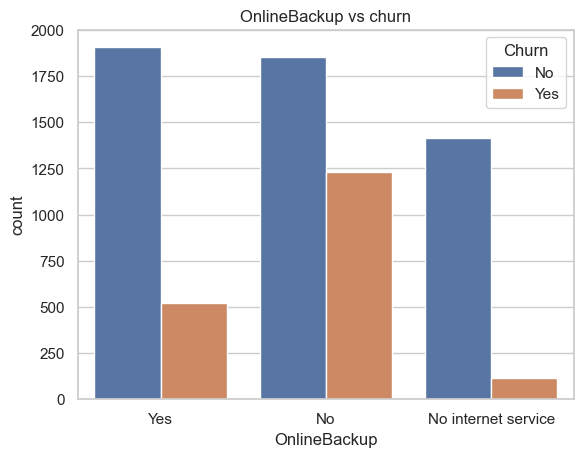

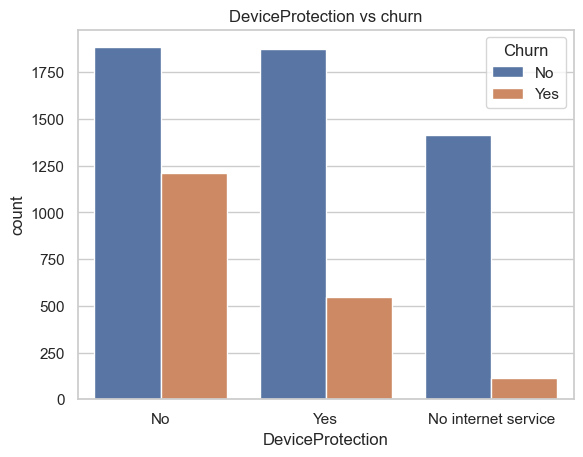

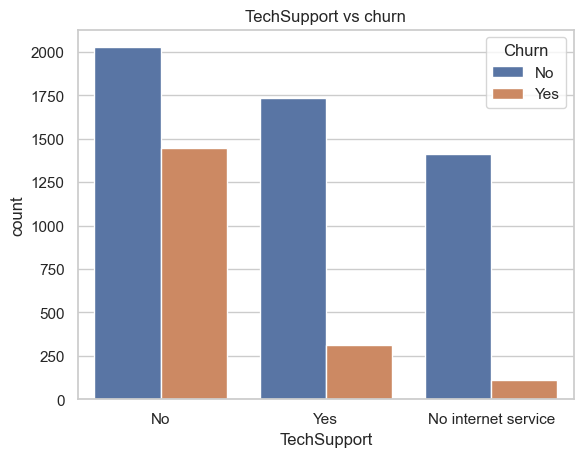

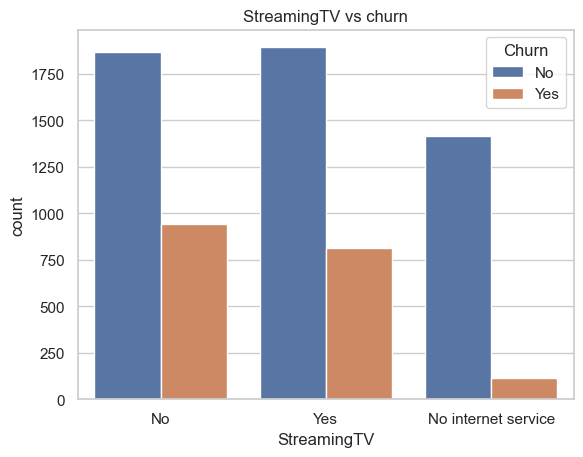

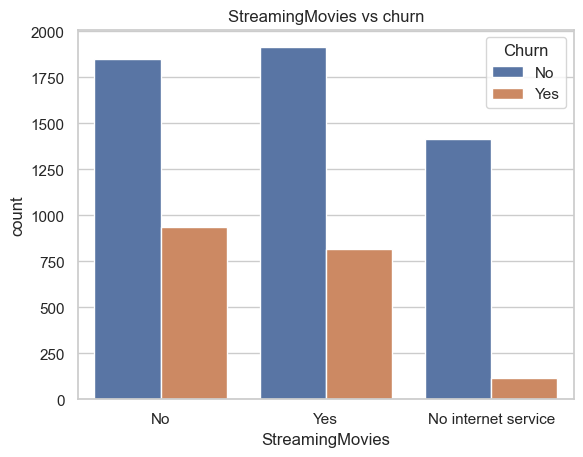

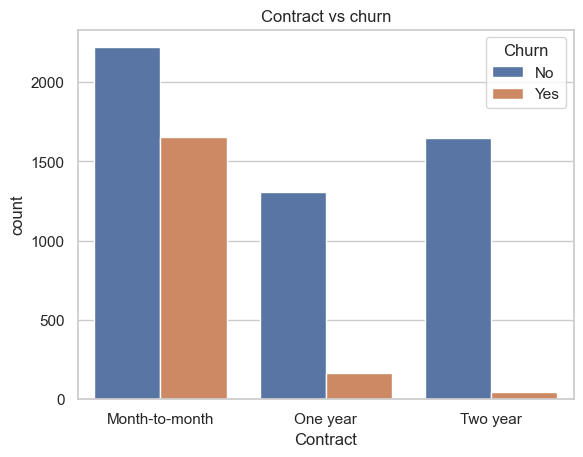

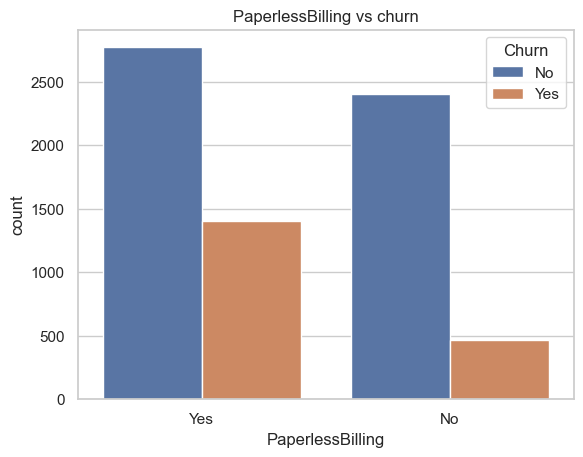

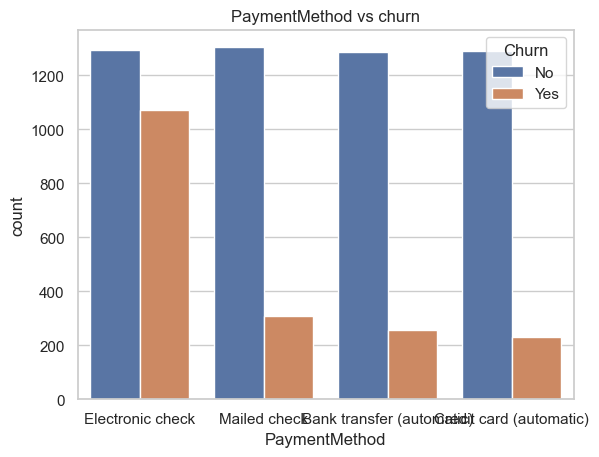

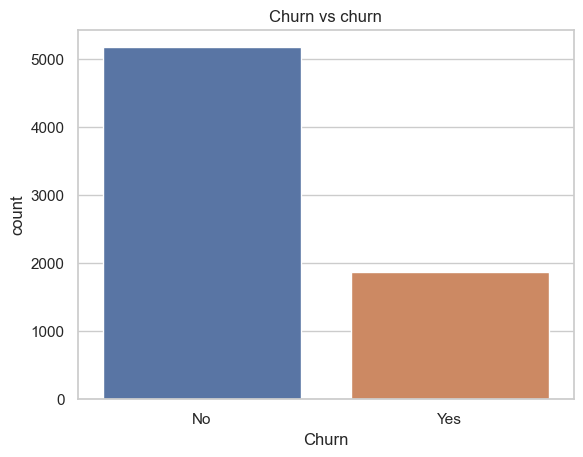

In [42]:
#categorical vs churn
for col in categorical_col:
    sns.countplot(data=df,x=col,hue='Churn')
    plt.title(f"{col} vs churn")
    plt.show()

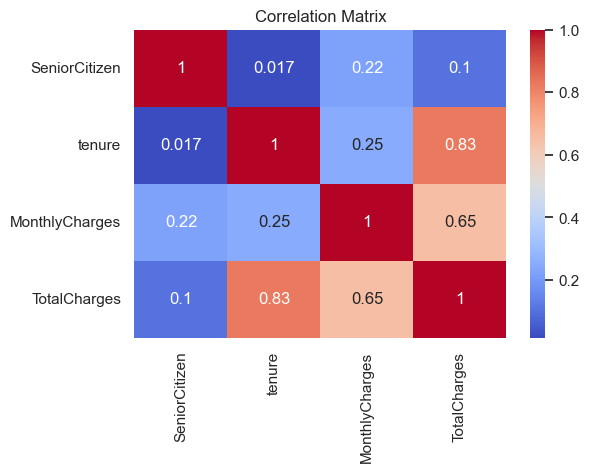

In [43]:
#correlation analysis can be done using numerical values only
plt.figure(figsize=(6,4))
sns.heatmap(df[numerical_col].corr(), annot=True, cmap= 'coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [44]:
# total charges depends on tenure and monthly charges

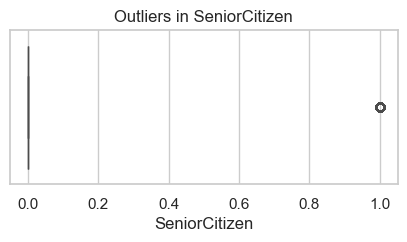

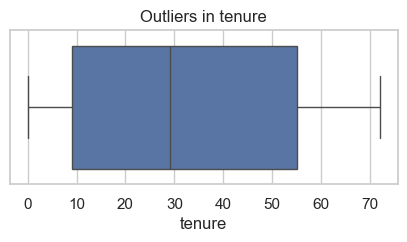

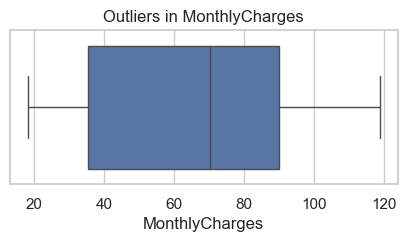

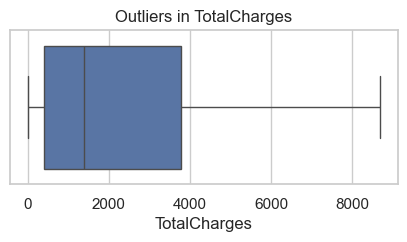

In [45]:
#outliers detection
for col in numerical_col:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

In [46]:
#customer with low tenure 
#customer with high monthly charges
#inmbalanced and correlated dataset

In [47]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
df_clean=df.copy()

In [49]:
df_clean.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
df_clean.drop(columns=['customerID'],inplace=True)

In [51]:
df_clean['TotalCharges']=pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

In [52]:
df_clean.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [53]:
df_clean.drop_duplicates(inplace=True)

In [54]:
for col in df_clean.select_dtypes(include='object'):
    df_clean[col]= df_clean[col].str.strip()

In [55]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [56]:
# Feature Engineering

In [57]:
# encode target variable because ml model needs neumerical targets
df_clean['Churn'] = df_clean['Churn'].map({'Yes' : 1, 'No' : 0})

In [58]:
#convert binary categorical features
binary_cat_col=[
    col for col in df_clean.select_dtypes(include='object').columns
    if df_clean[col].nunique() == 2

]
binary_cat_col

['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

In [59]:

for col in binary_cat_col:
    df_clean[col] = df_clean[col].map({'Yes':1, 'No':0,'Male':1,'Female':0})

In [60]:
#creating new feature
def tenure_group(tenure):
    if tenure <=12:
        return '0-1 year'
    elif tenure <=24:
         return '1-2 year'
    elif tenure <=48:
         return '2-4 year'
    else:
         return '4+ year'
    
df_clean['tenureGrp']=df_clean['tenure'].apply(tenure_group)   

In [61]:
# create charge intensity feature
df_clean['HighMonthlyCharge'] = (df_clean['MonthlyCharges'] > df_clean['MonthlyCharges'].median()).astype(int)

In [62]:
# service usage aggregation
# count how many services used by a customer
service_cols = [
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

df_clean['TotalServices'] = (df_clean[service_cols] == 'Yes').sum(axis=1)

In [63]:
df_clean[service_cols+['TotalServices']].head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices
0,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,No,No,2
2,Yes,Yes,No,No,No,No,2
3,Yes,No,Yes,Yes,No,No,3
4,No,No,No,No,No,No,0


In [64]:
#contract risk feature 
# small contract churn more
df_clean['shortContract']=(df_clean['Contract'] == 'Month-to-month').astype(int)

In [65]:
df_clean['shortContract'].head() #1->month to month 0-> one or more yuears


0    1
1    0
2    1
3    0
4    1
Name: shortContract, dtype: int64

In [66]:
df_clean['electronicuser']=( df_clean['PaymentMethod'] == 'Electronic check').astype(int)

In [67]:
df_clean['electronicuser'].head()

0    1
1    0
2    0
3    0
4    1
Name: electronicuser, dtype: int64

In [68]:
#one hot encoding
df_final= pd.get_dummies( df_clean, drop_first = True)

In [69]:
df_final.astype(int).head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,HighMonthlyCharge,TotalServices,shortContract,electronicuser,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenureGrp_1-2 year,tenureGrp_2-4 year,tenureGrp_4+ year
0,0,0,1,0,1,0,1,29,29,0,0,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,0,34,1,0,56,1889,0,0,2,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1,0
2,1,0,0,0,2,1,1,53,108,1,0,2,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,45,0,0,42,1840,0,0,3,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0
4,0,0,0,0,2,1,1,70,151,1,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [70]:
# Data cleaning ensured correct data types, handled missing values, removed duplicates, and standardized categorical variables. Feature engineering introduced customer lifecycle, service usage intensity, contract risk, and payment behavior features to better capture churn drivers.

In [71]:
## Model Building
#x--> feature input, independent variables
#y--->target output, dependent

In [72]:
X = df_final.drop(columns=['Churn'])
y= df_final['Churn']

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state= 42, stratify =y)

In [74]:
#identify col that need scaling only continuous numerical cols not binary or indicator features
num_col=['tenure','MonthlyCharges','TotalCharges']

In [75]:
#scaling (train data only)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[num_col] = scaler.fit_transform(X_train[num_col])
X_test[num_col]= scaler.transform(X_test[num_col])

In [76]:
X_train[num_col].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.616000e+03,5.616000e+03,5.616000e+03
mean,6.958663e-17,-3.694417e-16,-1.394896e-16
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322908e+00,-1.552059e+00,-1.006549e+00
25%,-9.558101e-01,-9.656039e-01,-8.288621e-01
50%,-1.400367e-01,1.848460e-01,-3.950579e-01
75%,9.612573e-01,8.303624e-01,6.667727e-01
max,1.613876e+00,1.791982e+00,2.810238e+00


In [77]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5616, 37) (1405, 37)
Churn
0    0.735577
1    0.264423
Name: proportion, dtype: float64
Churn
0    0.735231
1    0.264769
Name: proportion, dtype: float64


In [78]:
#class imbalance handeling using smote #smote on train never on test
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote= smote.fit_resample(X_train, y_train)

In [79]:
X_train_smote.shape
y_train_smote.shape

(8262,)

In [80]:
y_train_smote.value_counts()

Churn
1    4131
0    4131
Name: count, dtype: int64

In [81]:
#Baseline model training to train the model using logistic regression for binary classification use logistic regression
from sklearn.linear_model import LogisticRegression
log_model= LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [82]:
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

In [83]:
#Model evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score;
print("Confusion matrix")
print(confusion_matrix(y_test, y_pred_log))
print("\n Classificatio0n report")
print(classification_report(y_test, y_pred_log))
print("\n roc_auc")
print(roc_auc_score(y_test, y_pred_log))

Confusion matrix
[[830 203]
 [123 249]]

 Classificatio0n report
              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1033
           1       0.55      0.67      0.60       372

    accuracy                           0.77      1405
   macro avg       0.71      0.74      0.72      1405
weighted avg       0.79      0.77      0.77      1405


 roc_auc
0.7364199169347032


In [84]:
#roc_auc is good but not excellent try another model


In [85]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
#prediction
y_pred_dt= dt_model.predict(X_test)
y_prob_dt= dt_model.predict_proba(X_test)[:,1]

In [87]:
#model evaluation
print('Confusion matrix')
print(confusion_matrix(y_test, y_pred_dt))
print('classification report')
print(classification_report(y_test, y_pred_dt))
print('roc_auc ')
print(roc_auc_score(y_test, y_prob_dt))

Confusion matrix
[[705 328]
 [ 66 306]]
classification report
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       372

    accuracy                           0.72      1405
   macro avg       0.70      0.75      0.69      1405
weighted avg       0.80      0.72      0.74      1405

roc_auc 
0.8278620054335946


In [88]:
#roc_auc is good

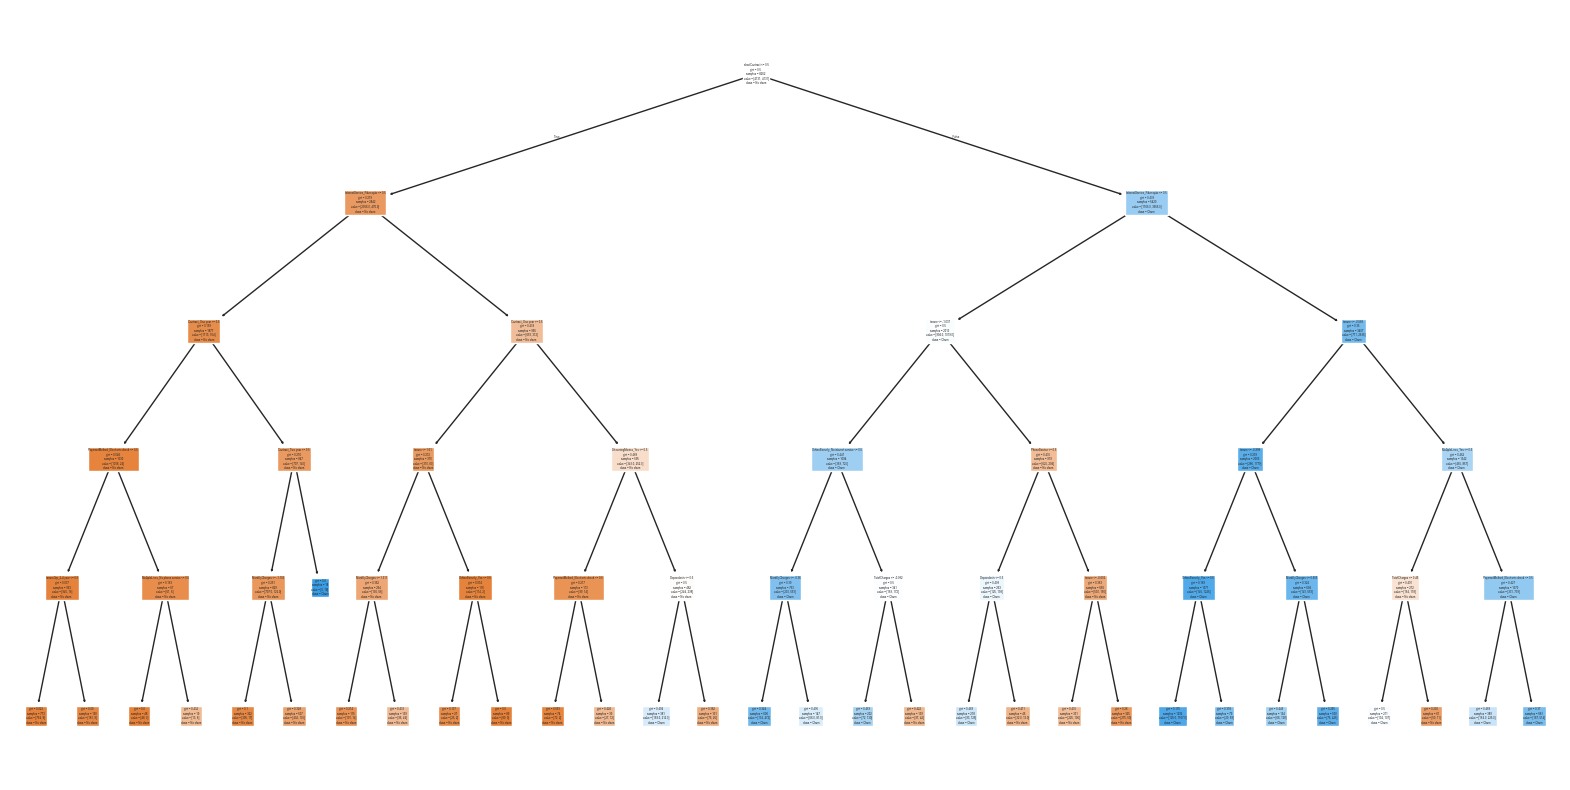

In [89]:
#visualization of decission tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    feature_names= X_train.columns,
    class_names= ['No churn','Churn'],
    filled= True
)
plt.show()

In [90]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators= 200, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
#prediction
y_pred_rf= rf_model.predict(X_test)
y_prob_rf= rf_model.predict_proba(X_test)[:,1]

In [92]:
# evaluation
print("Confusion matrix")
print(confusion_matrix(y_test,y_pred_rf))
print("Classification report")
print(classification_report(y_test,y_pred_rf))
print("roc_auc")
print(roc_auc_score(y_test,y_prob_rf))

Confusion matrix
[[860 173]
 [156 216]]
Classification report
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.58      0.57       372

    accuracy                           0.77      1405
   macro avg       0.70      0.71      0.70      1405
weighted avg       0.77      0.77      0.77      1405

roc_auc
0.8161763940501098


In [93]:
# roc_auc is good

In [94]:
from sklearn.svm import SVC
svm_model = SVC( probability=True,
    kernel='rbf',
    random_state=42)
svm_model.fit(X_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [95]:
#prediction
y_pred_svm= svm_model.predict(X_test)
y_prob_svm= svm_model.predict_proba(X_test)[:,1]

In [96]:
#evaluation
print("Confusion matrix")
print(confusion_matrix(y_test,y_pred_svm))
print("Classification report")
print(classification_report(y_test,y_pred_svm))
print("roc_auc")
print(roc_auc_score(y_test,y_prob_svm))

Confusion matrix
[[847 186]
 [127 245]]
Classification report
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.57      0.66      0.61       372

    accuracy                           0.78      1405
   macro avg       0.72      0.74      0.73      1405
weighted avg       0.79      0.78      0.78      1405

roc_auc
0.8251673276499183


In [97]:
#it is also good

In [98]:
#XG boost model
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

C:\Users\souja\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:04:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [99]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [100]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

[[851 182]
 [155 217]]
              precision    recall  f1-score   support

           0       0.85      0.82      0.83      1033
           1       0.54      0.58      0.56       372

    accuracy                           0.76      1405
   macro avg       0.69      0.70      0.70      1405
weighted avg       0.77      0.76      0.76      1405

ROC AUC: 0.8068796906390199


In [101]:
#model comparison table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'SVM',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.767972   0.550885  0.669355  0.604369  0.836720
1        Decision Tree  0.719573   0.482650  0.822581  0.608350  0.827862
2        Random Forest  0.765836   0.555270  0.580645  0.567674  0.816176
3                  SVM  0.777224   0.568445  0.658602  0.610212  0.825167
4              XGBoost  0.760142   0.543860  0.583333  0.562905  0.806880


In [102]:
results= results.sort_values(by='ROC-AUC' , ascending=False)
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.767972   0.550885  0.669355  0.604369  0.836720
1        Decision Tree  0.719573   0.482650  0.822581  0.608350  0.827862
3                  SVM  0.777224   0.568445  0.658602  0.610212  0.825167
2        Random Forest  0.765836   0.555270  0.580645  0.567674  0.816176
4              XGBoost  0.760142   0.543860  0.583333  0.562905  0.806880


In [103]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

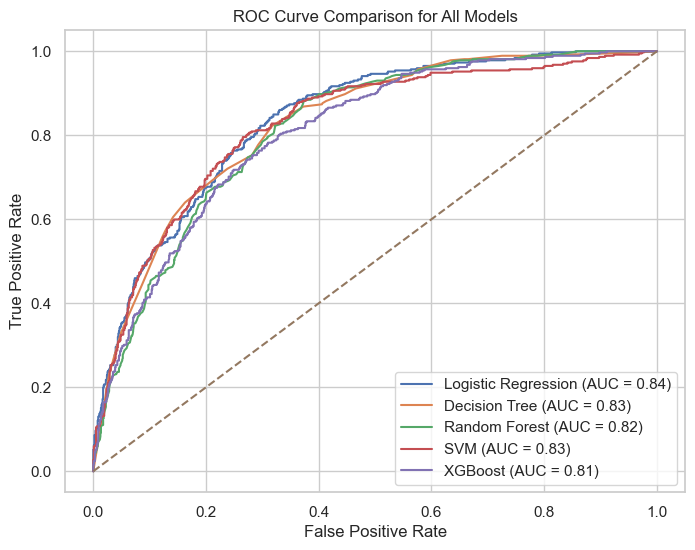

In [104]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log,
         label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.2f})")

plt.plot(fpr_dt, tpr_dt,
         label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.2f})")

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})")

plt.plot(fpr_svm, tpr_svm,
         label=f"SVM (AUC = {roc_auc_score(y_test, y_prob_svm):.2f})")

plt.plot(fpr_xgb, tpr_xgb,
         label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for All Models")

plt.legend()
plt.show()

In [105]:
#According to roc auc score highest accuracy achieved by logistic regression , so this is the final model

In [106]:
#Choosing best model
print(results.sort_values(by='ROC-AUC', ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.767972   0.550885  0.669355  0.604369  0.836720
1        Decision Tree  0.719573   0.482650  0.822581  0.608350  0.827862
3                  SVM  0.777224   0.568445  0.658602  0.610212  0.825167
2        Random Forest  0.765836   0.555270  0.580645  0.567674  0.816176
4              XGBoost  0.760142   0.543860  0.583333  0.562905  0.806880


In [107]:
#for churn project we prioritize recall also so decision tree is best model till now . 
# next we do threshold tuning for final model selection

In [108]:
import numpy as np

y_pred_log_custom = np.where(y_prob_log > 0.4, 1, 0)
y_pred_dt_custom = np.where(y_prob_dt > 0.4, 1, 0)
y_pred_rf_custom = np.where(y_prob_rf > 0.4, 1, 0)
y_pred_svm_custom = np.where(y_prob_svm > 0.4, 1, 0)
y_pred_xgb_custom = np.where(y_prob_xgb > 0.4, 1, 0)

In [109]:
from sklearn.metrics import recall_score

print("Recall after threshold tuning:\n")

print("Logistic Regression:", recall_score(y_test, y_pred_log_custom))
print("Decision Tree:", recall_score(y_test, y_pred_dt_custom))
print("Random Forest:", recall_score(y_test, y_pred_rf_custom))
print("SVM:", recall_score(y_test, y_pred_svm_custom))
print("XGBoost:", recall_score(y_test, y_pred_xgb_custom))

Recall after threshold tuning:

Logistic Regression: 0.7849462365591398
Decision Tree: 0.8225806451612904
Random Forest: 0.6908602150537635
SVM: 0.696236559139785
XGBoost: 0.6639784946236559


In [110]:
#updated comparison table
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score
import pandas as pd

results_tuned = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost'],

    'Accuracy': [
        accuracy_score(y_test, y_pred_log_custom),
        accuracy_score(y_test, y_pred_dt_custom),
        accuracy_score(y_test, y_pred_rf_custom),
        accuracy_score(y_test, y_pred_svm_custom),
        accuracy_score(y_test, y_pred_xgb_custom)
    ],

    'Precision': [
        precision_score(y_test, y_pred_log_custom),
        precision_score(y_test, y_pred_dt_custom),
        precision_score(y_test, y_pred_rf_custom),
        precision_score(y_test, y_pred_svm_custom),
        precision_score(y_test, y_pred_xgb_custom)
    ],

    'Recall': [
        recall_score(y_test, y_pred_log_custom),
        recall_score(y_test, y_pred_dt_custom),
        recall_score(y_test, y_pred_rf_custom),
        recall_score(y_test, y_pred_svm_custom),
        recall_score(y_test, y_pred_xgb_custom)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_log_custom),
        f1_score(y_test, y_pred_dt_custom),
        f1_score(y_test, y_pred_rf_custom),
        f1_score(y_test, y_pred_svm_custom),
        f1_score(y_test, y_pred_xgb_custom)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results_tuned.sort_values(by='Recall', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Decision Tree,0.719573,0.482650,0.822581,0.608350,0.827862
0,Logistic Regression,0.744484,0.511384,0.784946,0.619300,0.836720
3,SVM,0.772954,0.556989,0.696237,0.618877,0.825167
2,Random Forest,0.743060,0.510934,0.690860,0.587429,0.816176
4,XGBoost,0.753737,0.527778,0.663978,0.588095,0.806880


In [111]:
best_model = results_tuned.sort_values(by='Recall', ascending=False).iloc[0]

print("Best Model Based on Recall:\n")
print(best_model)

Best Model Based on Recall:

Model        Decision Tree
Accuracy          0.719573
Precision          0.48265
Recall            0.822581
F1 Score           0.60835
ROC-AUC           0.827862
Name: 1, dtype: object


In [112]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_dt_custom))
print(classification_report(y_test, y_pred_dt_custom))

[[705 328]
 [ 66 306]]
              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1033
           1       0.48      0.82      0.61       372

    accuracy                           0.72      1405
   macro avg       0.70      0.75      0.69      1405
weighted avg       0.80      0.72      0.74      1405



In [113]:
# DEPLOYMENT using power bi

In [114]:
#create final dataset
df_dashboard = X_test.copy()
df_dashboard['Actual_churn'] = y_test
df_dashboard['Predicted_churn'] = y_pred_dt_custom
df_dashboard['Churn_prob'] = y_prob_dt

In [115]:
#this file is power bi data source
df_dashboard.to_csv("churn_dashboard_data.csv", index=False)

In [116]:
import joblib

joblib.dump(dt_model, "churn_model.pkl")

['churn_model.pkl']